# 01 — Data & a Bag-of-Words Baseline

Before any neural net, we build the simplest model that could possibly work:
a **Bag-of-Words** next-word predictor. It will be mediocre — and crucially,
it throws away word order. That measured failure motivates everything later.

In [1]:
import os
import re
import json
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(1337)

## Get the data

TinyShakespeare (~1MB). Downloaded once and cached in `data/`.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "data/shakespeare.txt"

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    print("Downloading TinyShakespeare...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print("Characters:", len(text))
print("----- sample -----")
print(text[:250])

Characters: 1115394
----- sample -----
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



## Word-level tokenization

"Bag of **words**" is about words, so here we tokenize on words. We lowercase,
split words and punctuation, cap the vocabulary to the most common words, and
map everything else to `<unk>`.

In [3]:
def tokenize_words(s: str) -> list[str]:
    # words and standalone punctuation become tokens
    return re.findall(r"[a-z]+|[^a-z\s]", s.lower())

VOCAB_SIZE = 2000  # cap for a tractable BoW model

class WordTokenizer:
    def __init__(self, corpus: str, max_vocab: int = VOCAB_SIZE):
        counts = Counter(tokenize_words(corpus))
        most_common = [w for w, _ in counts.most_common(max_vocab - 1)]
        self.itos = ["<unk>"] + most_common
        self.stoi = {w: i for i, w in enumerate(self.itos)}
        self.vocab_size = len(self.itos)

    def encode(self, s: str) -> list[int]:
        unk = self.stoi["<unk>"]
        return [self.stoi.get(w, unk) for w in tokenize_words(s)]

    def decode(self, ids: list[int]) -> str:
        return " ".join(self.itos[i] for i in ids)

tok = WordTokenizer(text)
print("Vocab size:", tok.vocab_size)

Vocab size: 2000


Sanity check: encoding then decoding a known-in-vocab phrase round-trips.

In [4]:
sample = "to be or not to be"
ids = tok.encode(sample)
assert tok.decode(ids) == sample, tok.decode(ids)
print("round-trip ok:", ids, "->", tok.decode(ids))

round-trip ok: [8, 26, 61, 19, 8, 26] -> to be or not to be


## Train / validation split

We hold out the last 10% to measure generalization honestly.

In [5]:
ids_all = tok.encode(text)
n = len(ids_all)
split = int(0.9 * n)
train_ids = ids_all[:split]
val_ids = ids_all[split:]
print(f"tokens: {n} (train {len(train_ids)}, val {len(val_ids)})")

tokens: 262927 (train 236634, val 26293)


## The Bag-of-Words representation

To predict the next word we look at the previous `CONTEXT` words — but we
represent them as an **unordered count vector** of length `vocab_size`. The
position of each word is discarded; only *how many times* each appears remains.

In [6]:
CONTEXT = 8

def make_bow_dataset(ids: list[int], context: int, vocab_size: int, limit: int):
    # returns X: (N, vocab_size) float counts, Y: (N,) next-word ids
    xs, ys = [], []
    step = max(1, (len(ids) - context - 1) // limit)  # subsample for speed
    for i in range(0, len(ids) - context - 1, step):
        window = ids[i:i + context]
        vec = torch.zeros(vocab_size)
        for w in window:
            vec[w] += 1.0
        xs.append(vec)
        ys.append(ids[i + context])
    return torch.stack(xs), torch.tensor(ys)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

Xtr, Ytr = make_bow_dataset(train_ids, CONTEXT, tok.vocab_size, limit=20000)
Xva, Yva = make_bow_dataset(val_ids, CONTEXT, tok.vocab_size, limit=4000)
Xtr, Ytr, Xva, Yva = Xtr.to(device), Ytr.to(device), Xva.to(device), Yva.to(device)
print("BoW train X:", tuple(Xtr.shape), "val X:", tuple(Xva.shape))

BoW train X: (21512, 2000) val X: (4381, 2000)


The model is a single linear layer: count vector -> next-word logits. This is
multinomial logistic regression — about as simple as a learnable model gets.

In [7]:
class BoWModel(nn.Module):
    def __init__(self, vocab_size: int):
        super().__init__()
        self.fc = nn.Linear(vocab_size, vocab_size)

    def forward(self, x):
        return self.fc(x)

bow = BoWModel(tok.vocab_size).to(device)
print("BoW params:", sum(p.numel() for p in bow.parameters()))

BoW params: 4002000


## Train it

Plain full-batch-ish training with AdamW and cross-entropy.

In [8]:
def evaluate(model, X, Y) -> float:
    model.eval()
    with torch.no_grad():
        loss = nn.functional.cross_entropy(model(X), Y)
    model.train()
    return float(loss)

opt = torch.optim.AdamW(bow.parameters(), lr=1e-2)
EPOCHS = 60
losses = []
for epoch in range(EPOCHS):
    logits = bow(Xtr)
    loss = nn.functional.cross_entropy(logits, Ytr)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

val_loss = evaluate(bow, Xva, Yva)
bow_val_ppl = float(torch.exp(torch.tensor(val_loss)))
print(f"BoW final train loss {losses[-1]:.3f} | val loss {val_loss:.3f} | val perplexity {bow_val_ppl:.1f}")

BoW final train loss 2.939 | val loss 5.576 | val perplexity 264.1


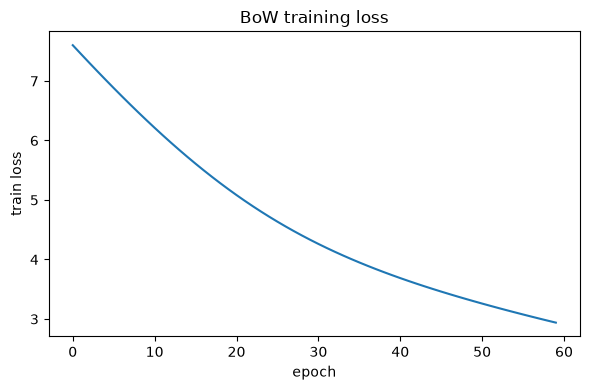

In [9]:
os.makedirs("assets", exist_ok=True)
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("train loss"); plt.title("BoW training loss")
plt.tight_layout()
plt.savefig("assets/01_bow_loss.png", dpi=120)
plt.show()

## The punchline: order is gone

Two different orderings of the same words produce the **identical** BoW vector,
so the model gives the **identical** prediction. A real language needs order —
this is the measured flaw we'll fix with attention.

In [10]:
phrase_a = tok.encode("the king is dead")
phrase_b = list(reversed(phrase_a))

def bow_vec(ids):
    v = torch.zeros(tok.vocab_size, device=device)
    for w in ids:
        v[w] += 1.0
    return v

va, vb = bow_vec(phrase_a), bow_vec(phrase_b)
assert torch.equal(va, vb), "BoW vectors should be identical regardless of order"

with torch.no_grad():
    pa = bow(va.unsqueeze(0))
    pb = bow(vb.unsqueeze(0))
assert torch.allclose(pa, pb), "predictions should be identical regardless of order"
print("Confirmed: '", tok.decode(phrase_a), "' and '", tok.decode(phrase_b),
      "' give identical predictions. Order is invisible to BoW.")

Confirmed: ' the king is dead ' and ' dead is king the ' give identical predictions. Order is invisible to BoW.


## Save the baseline number

Notebook 02 will try to beat this perplexity with dense embeddings.

In [11]:
os.makedirs("assets", exist_ok=True)
with open("assets/phase1_metrics.json", "w") as f:
    json.dump({"bow_val_perplexity": bow_val_ppl,
               "bow_params": sum(p.numel() for p in bow.parameters()),
               "context": CONTEXT, "vocab_size": tok.vocab_size}, f, indent=2)
print("Saved baseline:", bow_val_ppl)

Saved baseline: 264.1396789550781
